In [1]:
import matplotlib.pyplot as plt

from pathlib import Path
from maploc.osm.viz import GeoPlotter
from maploc.osm.tiling import TileManager
from maploc.osm.viz import Colormap, plot_nodes
from maploc.utils.viz_2d import plot_images
from maploc.utils.geo import BoundaryBox, Projection
from maploc.utils.exif import EXIF
import cv2
from typing import Dict, Optional, Tuple
import numpy as np

In [2]:
# Custom Overrides to avoid pytorch
def parse_location_prior(
    exif: EXIF,
    prior_latlon: Optional[Tuple[float, float]] = None,
    prior_address: Optional[str] = None,
) -> np.ndarray:
    latlon = None
    if latlon is None:
        geo = exif.extract_geo()
        if geo:
            alt = geo.get("altitude", 0)  # read if available
            latlon = (geo["latitude"], geo["longitude"], alt)
        else:
            raise ValueError(
                "No location prior given or found in the image EXIF metadata: "
                "maybe provide the name of a street, building or neighborhood?"
            )
    return np.array(latlon)

def read_input_image(
    image_path: str,
    prior_latlon: Optional[Tuple[float, float]] = None,
    prior_address: Optional[str] = None,
    focal_length: Optional[float] = None,
    tile_size_meters: int = 64,
) -> Tuple[np.ndarray, Tuple[str, str], Projection, BoundaryBox]:
    image = read_image(image_path)
    with open(image_path, "rb") as fid:
        exif = EXIF(fid, lambda: image.shape[:2])
        latlon = parse_location_prior(exif, prior_latlon, prior_address)
        proj = Projection(*latlon)
        center = proj.project(latlon)
        bbox = BoundaryBox(center, center) + tile_size_meters
        return image, None, proj, bbox

def read_image(path, grayscale=False):
    if grayscale:
        mode = cv2.IMREAD_GRAYSCALE
    else:
        mode = cv2.IMREAD_COLOR
    image = cv2.imread(str(path), mode)
    if image is None:
        raise ValueError(f"Cannot read image {path}.")
    if not grayscale and len(image.shape) == 3:
        image = np.ascontiguousarray(image[:, :, ::-1])  # BGR to RGB
    return image

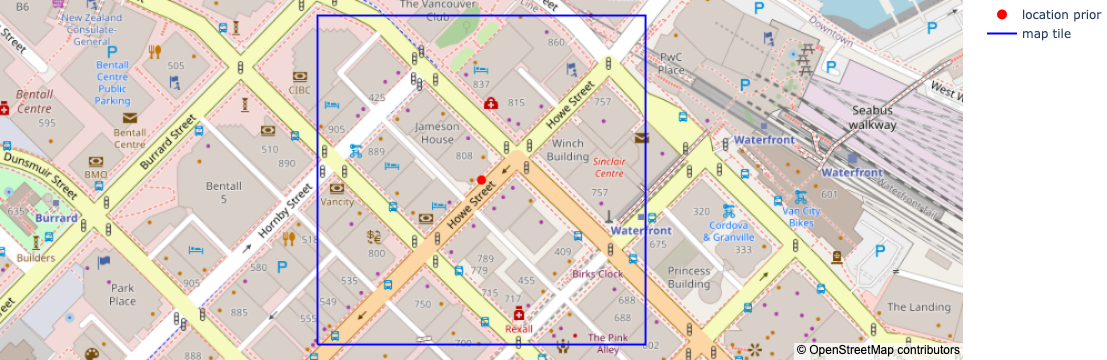

In [3]:
# no EXIF data: provide a coarse location prior as address
image_path = "assets/query_zurich_1.JPG"
prior_address = "ETH CAB Zurich"

# Try out these other queries!
# image_path = "assets/query_vancouver_1.JPG"
# prior_address = "Vancouver Waterfront Station"

# image_path = "assets/query_vancouver_2.JPG"
image_path = "assets/query_vancouver_3.JPG"
# prior_address = None # here we load the location prior from the exif

image, gravity, proj, bbox = read_input_image(
    image_path,
    tile_size_meters=128,  # try 64, 256, etc.
)

# Show the query area in an interactive map
plot = GeoPlotter(zoom=16)
plot.points(proj.latlonalt[:2], "red", name="location prior", size=10)
plot.bbox(proj.unproject(bbox), "blue", name="map tile")
plot.fig.show()

# Using the OSM TileManager

In [4]:
# Query OpenStreetMap for this area
%time
tiler = TileManager.from_bbox(proj, bbox + 10, ppm=2, path=Path('none.json'))

CPU times: user 4 μs, sys: 1 μs, total: 5 μs
Wall time: 7.87 μs


In [5]:
bbox_degrees = proj.unproject(bbox)
(south, west), (north, east) = bbox_degrees.min_, bbox_degrees.max_

In [6]:
print(f"POLYGON(({west} {south}, {west} {north},{east} {north}, {east} {south}, {west} {south}))")

POLYGON((-123.11701768207513 49.28465184777454, -123.11701768207513 49.286953680762764,-123.1134989026913 49.286953680762764, -123.1134989026913 49.28465184777454, -123.11701768207513 49.28465184777454))


In [7]:
canvas = tiler.query(bbox)

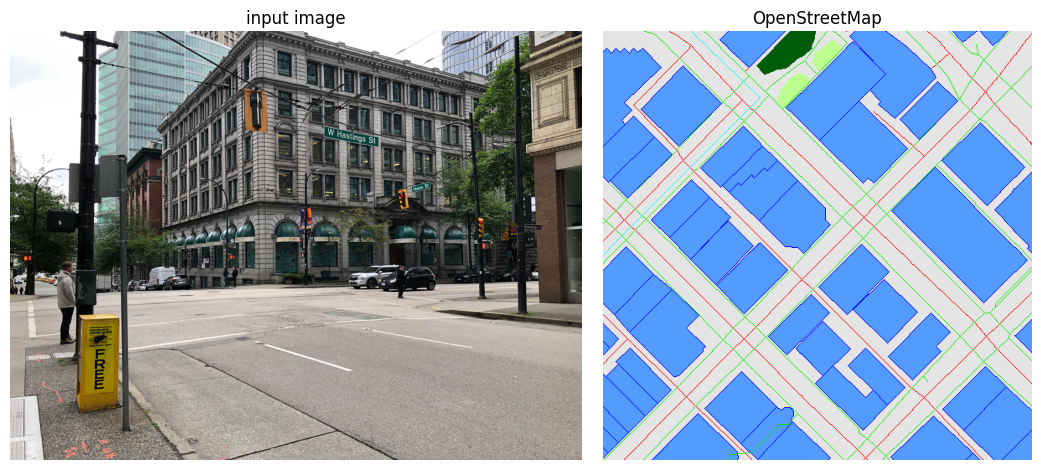

In [8]:
# Show the inputs to the model: image and raster map
map_viz = Colormap.apply(canvas.raster)
plot_images([image, map_viz], titles=["input image", "OpenStreetMap"])

In [9]:
rgb_image = np.transpose(canvas.raster, (1, 2, 0))
cv2.imwrite('osm.png', rgb_image)

True

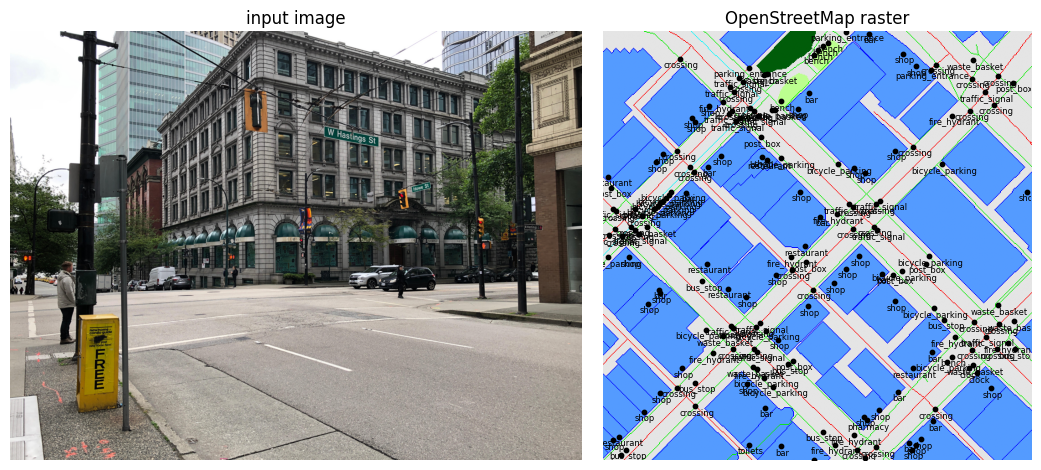

In [10]:
plot_images([image, map_viz], titles=["input image", "OpenStreetMap raster"])
plot_nodes(1, canvas.raster[2], fontsize=6, size=10)

# Using the GeoPandas TileManager (and fetching from vector tiles)

In [12]:
%time
tiler2 = TileManager.from_bbox(proj, bbox + 10, ppm=2, source='earth')

CPU times: user 3 μs, sys: 1 μs, total: 4 μs
Wall time: 11 μs


NameError: name 'parse_osm_tags_to_group' is not defined

In [ ]:
canvas2 = tiler2.query(bbox)

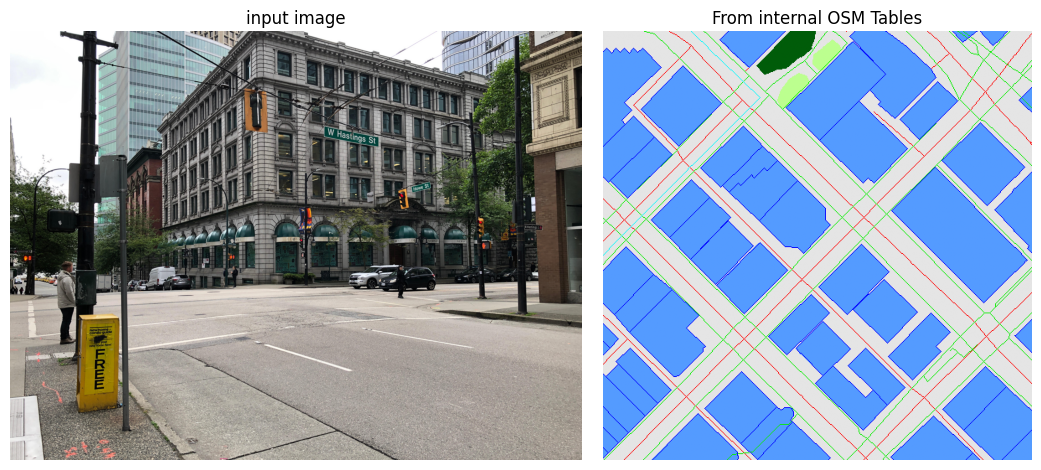

In [13]:
# Show the inputs to the model: image and raster map
map_viz2 = Colormap.apply(canvas2.raster)
plot_images([image, map_viz2], titles=["input image", "From internal OSM Tables"])

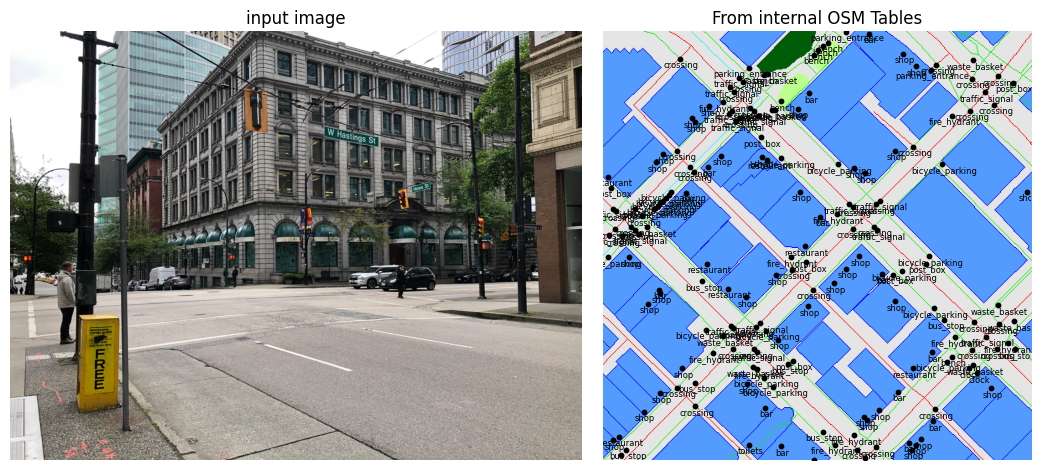

In [14]:
plot_images([image, map_viz2], titles=["input image", "From internal OSM Tables"])
plot_nodes(1, canvas2.raster[2], fontsize=6, size=10)